# Tapered CCA experiments

This notebook studies high-dimensional canonical correlation analysis (CCA) when the two views `X` and `Y` are independent. Under the null, the population canonical correlations are zero, but ordinary empirical CCA can still find large correlations when `p/n` is large.

The notebook follows one clean combined structure:

1. Ordinary CCA inflation under independence.
2. AR(1) covariance structure visualization.
3. Tapered CCA using only `Sxx` and `Syy`.
4. Tapered CCA using `Sxx`, `Syy`, and `Sxy`.
5. Taper type comparison.
6. Bandwidth sensitivity.
7. Numerical stability diagnostics.

For final figures, increase `N_REP` to `30` or `50` in the configuration cell. The default is smaller so the notebook remains pleasant to run interactively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260615
N = 200
PHI = 0.6
P_RATIOS = np.round(np.arange(0.05, 0.951, 0.05), 2)

# Raise this to 30 or 50 for smoother final plots.
N_REP = 8

RIDGE = 1e-3
EIG_FLOOR = 1e-8
BANDWIDTHS = [2, 5, 10, 20, 50]
K_TRACK = 5

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
})

## Helper functions

The ordinary CCA helper mirrors the usual QR/SVD computation. The tapered CCA helper computes sample covariance blocks, applies a taper matrix, adds a ridge to the within-view covariance matrices, clips tiny eigenvalues, and then computes the singular values of the whitened cross-covariance matrix.

The `mode` argument controls whether tapering is applied only to `Sxx` and `Syy` (`mode="within"`) or to all covariance blocks (`mode="all"`).

In [2]:
def cancor(X, Y, k=None):
    """Canonical correlations via centering, QR, and SVD."""
    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)
    Qx, _ = np.linalg.qr(Xc, mode="reduced")
    Qy, _ = np.linalg.qr(Yc, mode="reduced")
    s = np.linalg.svd(Qx.T @ Qy, compute_uv=False)
    return s if k is None else s[:k]


def ar1_matrix(n, p, phi, rng):
    """Generate rows from an ordered AR(1)-style feature process."""
    X = np.zeros((n, p))
    X[:, 0] = rng.standard_normal(n)
    noise_scale = np.sqrt(1 - phi**2)
    for j in range(1, p):
        X[:, j] = phi * X[:, j - 1] + noise_scale * rng.standard_normal(n)
    return X


def sample_covariance(X, Y=None):
    Xc = X - X.mean(axis=0)
    if Y is None:
        return (Xc.T @ Xc) / (X.shape[0] - 1)
    Yc = Y - Y.mean(axis=0)
    return (Xc.T @ Yc) / (X.shape[0] - 1)


def distance_matrix(p):
    i, j = np.indices((p, p))
    return np.abs(i - j)


def hard_taper_matrix(p, bandwidth):
    dist = distance_matrix(p)
    return (dist <= bandwidth).astype(float)


def linear_taper_matrix(p, bandwidth):
    dist = distance_matrix(p)
    return np.maximum(0.0, 1.0 - dist / bandwidth)


def exponential_taper_matrix(p, alpha):
    dist = distance_matrix(p)
    return alpha ** dist


def taper_matrix(p, taper_type="linear", bandwidth=10, alpha=0.8):
    if taper_type == "hard":
        return hard_taper_matrix(p, bandwidth)
    if taper_type == "linear":
        return linear_taper_matrix(p, bandwidth)
    if taper_type == "exponential":
        return exponential_taper_matrix(p, alpha)
    raise ValueError(f"Unknown taper_type: {taper_type}")


def regularized_inv_sqrt(S, ridge=RIDGE, eig_floor=EIG_FLOOR):
    """Return a stable inverse square root and raw eigenvalues before clipping."""
    S = (S + S.T) / 2
    p = S.shape[0]
    scale = np.trace(S) / p
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    S_reg = S + ridge * scale * np.eye(p)
    eig, U = np.linalg.eigh(S_reg)
    eig_clipped = np.maximum(eig, eig_floor * scale)
    inv_sqrt = (U * (1.0 / np.sqrt(eig_clipped))) @ U.T
    return inv_sqrt, eig


def tapered_cancor(
    X,
    Y,
    bandwidth=10,
    taper_type="linear",
    mode="within",
    ridge=RIDGE,
    eig_floor=EIG_FLOOR,
    alpha=0.8,
):
    """Tapered CCA singular values.

    mode="within" tapers Sxx and Syy only.
    mode="all" tapers Sxx, Syy, and Sxy.
    """
    if mode not in {"within", "all"}:
        raise ValueError("mode must be 'within' or 'all'")

    _, p = X.shape
    Sxx = sample_covariance(X)
    Syy = sample_covariance(Y)
    Sxy = sample_covariance(X, Y)
    T = taper_matrix(p, taper_type=taper_type, bandwidth=bandwidth, alpha=alpha)

    Sxx_tap = T * Sxx
    Syy_tap = T * Syy
    Sxy_tap = T * Sxy if mode == "all" else Sxy

    Sxx_invhalf, eig_x = regularized_inv_sqrt(Sxx_tap, ridge=ridge, eig_floor=eig_floor)
    Syy_invhalf, eig_y = regularized_inv_sqrt(Syy_tap, ridge=ridge, eig_floor=eig_floor)

    M = Sxx_invhalf @ Sxy_tap @ Syy_invhalf
    s = np.linalg.svd(M, compute_uv=False)
    return s, eig_x, eig_y


def summarize_curves(curves):
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "q10": np.quantile(curves, 0.10, axis=0),
        "q90": np.quantile(curves, 0.90, axis=0),
    }


def plot_mean_band(ax, x, curves, label, color, alpha=0.18, lw=2):
    summary = summarize_curves(curves)
    ax.plot(x, summary["mean"], label=label, color=color, lw=lw)
    ax.fill_between(x, summary["q10"], summary["q90"], color=color, alpha=alpha, linewidth=0)
    return summary


def final_value_text(label, curves):
    vals = curves[:, -1]
    over_one = np.mean(vals > 1.0)
    return f"{label:24s} mean={vals.mean():.3f}, sd={vals.std():.3f}, >1 rate={over_one:.2f}"

## Experiment 1: ordinary CCA inflation under independence

Here `X` and `Y` are independent Gaussian matrices. The true population canonical correlations are zero. The plot shows that ordinary empirical CCA still finds increasingly large correlations as `p/n` grows.

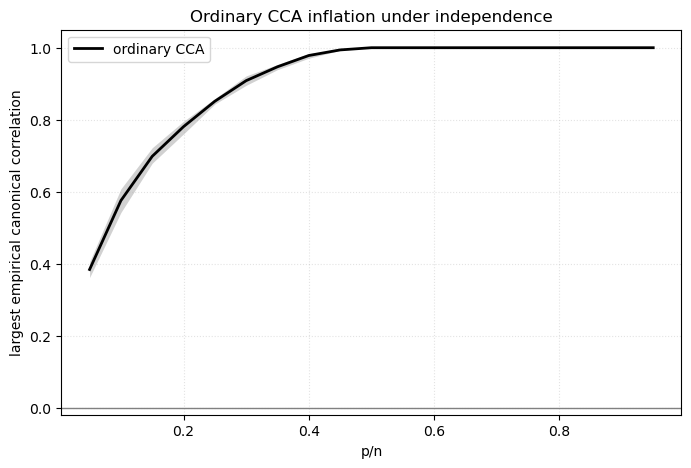

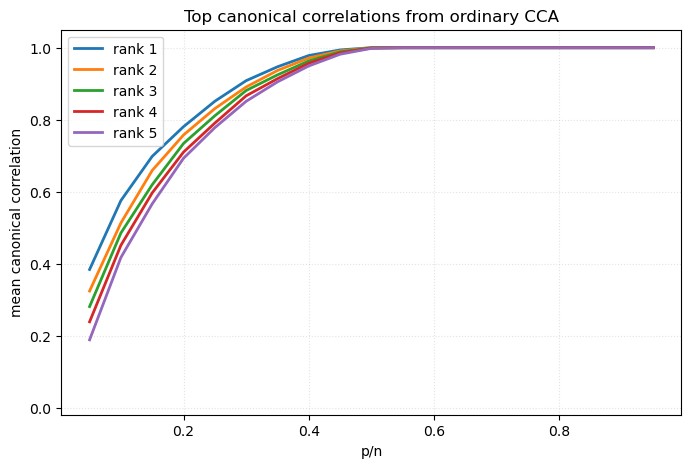

In [3]:
def run_ordinary_inflation(n=N, p_ratios=P_RATIOS, n_rep=N_REP, k_track=K_TRACK, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    largest = np.zeros((n_rep, len(p_ratios)))
    top = np.zeros((n_rep, len(p_ratios), k_track))

    for rep in range(n_rep):
        for i, ratio in enumerate(p_ratios):
            p = int(np.floor(n * ratio))
            X = rng.standard_normal((n, p))
            Y = rng.standard_normal((n, p))
            corrs = cancor(X, Y, k=k_track)
            largest[rep, i] = corrs[0]
            top[rep, i, :len(corrs)] = corrs
    return largest, top

ordinary_iid, ordinary_iid_top = run_ordinary_inflation()

fig, ax = plt.subplots()
plot_mean_band(ax, P_RATIOS, ordinary_iid, "ordinary CCA", "black")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("p/n")
ax.set_ylabel("largest empirical canonical correlation")
ax.set_title("Ordinary CCA inflation under independence")
ax.set_ylim(-0.02, 1.05)
ax.legend()
plt.show()

fig, ax = plt.subplots()
mean_top = ordinary_iid_top.mean(axis=0)
for j in range(K_TRACK):
    ax.plot(P_RATIOS, mean_top[:, j], lw=2, label=f"rank {j + 1}")
ax.set_xlabel("p/n")
ax.set_ylabel("mean canonical correlation")
ax.set_title("Top canonical correlations from ordinary CCA")
ax.set_ylim(-0.02, 1.05)
ax.legend()
plt.show()

## Experiment 2: AR(1) covariance structure and taper matrices

AR(1) data creates an ordered local structure: nearby features are strongly correlated and far-away features are weakly correlated. This is the setting where covariance tapering is scientifically meaningful.

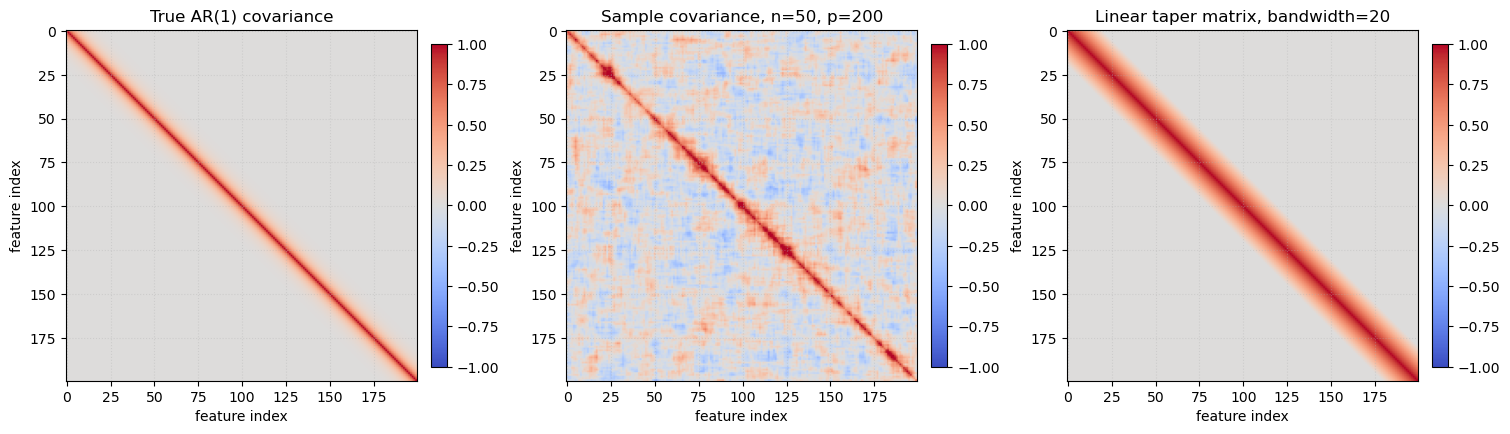

In [4]:
rng = np.random.default_rng(RNG_SEED + 1)
n_vis, p_vis, phi_vis = 50, 200, 0.8
X_vis = ar1_matrix(n_vis, p_vis, phi_vis, rng)
S_vis = sample_covariance(X_vis)
Sigma_true = phi_vis ** distance_matrix(p_vis)
T_vis = linear_taper_matrix(p_vis, bandwidth=20)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
plots = [
    (Sigma_true, "True AR(1) covariance"),
    (S_vis, "Sample covariance, n=50, p=200"),
    (T_vis, "Linear taper matrix, bandwidth=20"),
]
for ax, (mat, title) in zip(axes, plots):
    im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("feature index")
    ax.set_ylabel("feature index")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Experiment 3: taper only `Sxx` and `Syy`

This is the main regularized CCA version. The cross-covariance `Sxy` is left alone, while the within-view covariance matrices used in whitening are tapered and ridge-regularized.

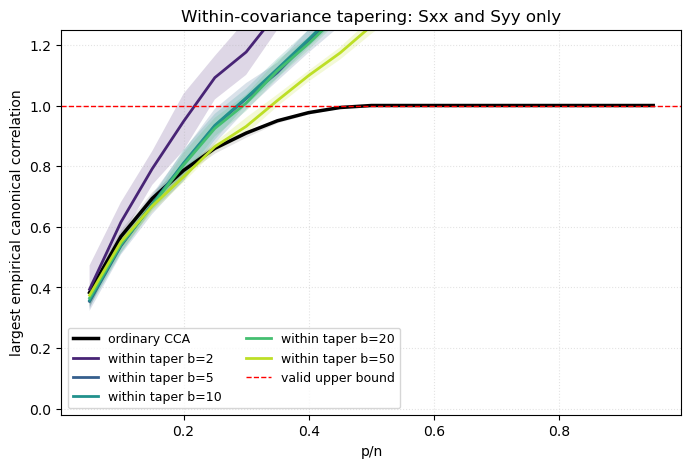

Final values at p/n = 0.95
ordinary CCA             mean=1.000, sd=0.000, >1 rate=1.00
within taper b=2         mean=2.424, sd=0.066, >1 rate=1.00
within taper b=5         mean=2.120, sd=0.039, >1 rate=1.00
within taper b=10        mean=2.147, sd=0.040, >1 rate=1.00
within taper b=20        mean=2.134, sd=0.032, >1 rate=1.00
within taper b=50        mean=1.935, sd=0.023, >1 rate=1.00


In [5]:
def run_taper_experiment(
    mode="within",
    taper_type="linear",
    bandwidths=BANDWIDTHS,
    n=N,
    phi=PHI,
    p_ratios=P_RATIOS,
    n_rep=N_REP,
    ridge=RIDGE,
    eig_floor=EIG_FLOOR,
    alpha=0.8,
    seed=RNG_SEED + 2,
):
    rng = np.random.default_rng(seed)
    ordinary = np.zeros((n_rep, len(p_ratios)))
    tapered = {b: np.zeros((n_rep, len(p_ratios))) for b in bandwidths}

    for rep in range(n_rep):
        for i, ratio in enumerate(p_ratios):
            p = int(np.floor(n * ratio))
            X = ar1_matrix(n, p, phi, rng)
            Y = ar1_matrix(n, p, phi, rng)
            ordinary[rep, i] = cancor(X, Y, k=1)[0]

            for b in bandwidths:
                corrs, _, _ = tapered_cancor(
                    X,
                    Y,
                    bandwidth=b,
                    taper_type=taper_type,
                    mode=mode,
                    ridge=ridge,
                    eig_floor=eig_floor,
                    alpha=alpha,
                )
                tapered[b][rep, i] = corrs[0]
    return ordinary, tapered

ordinary_ar1_within, within_results = run_taper_experiment(mode="within")

fig, ax = plt.subplots()
plot_mean_band(ax, P_RATIOS, ordinary_ar1_within, "ordinary CCA", "black", alpha=0.10, lw=2.5)
colors = plt.cm.viridis(np.linspace(0.10, 0.90, len(BANDWIDTHS)))
for color, b in zip(colors, BANDWIDTHS):
    plot_mean_band(ax, P_RATIOS, within_results[b], f"within taper b={b}", color)
ax.axhline(1, color="red", linestyle="--", lw=1, label="valid upper bound")
ax.set_xlabel("p/n")
ax.set_ylabel("largest empirical canonical correlation")
ax.set_title("Within-covariance tapering: Sxx and Syy only")
ax.set_ylim(-0.02, 1.25)
ax.legend(ncol=2, fontsize=9)
plt.show()

print("Final values at p/n =", P_RATIOS[-1])
print(final_value_text("ordinary CCA", ordinary_ar1_within))
for b in BANDWIDTHS:
    print(final_value_text(f"within taper b={b}", within_results[b]))

## Experiment 4: taper `Sxx`, `Syy`, and `Sxy`

This version is more aggressive because it assumes the cross-covariance block also has local structure. That assumption is reasonable only when feature `i` in `X` corresponds meaningfully to feature `i` in `Y`.

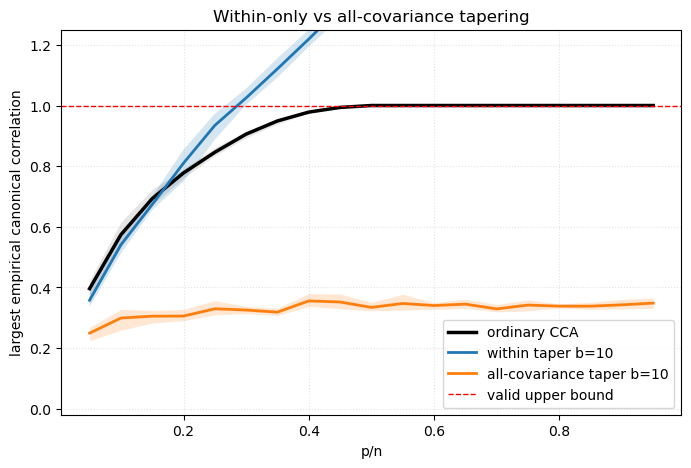

Final values at p/n = 0.95
ordinary CCA             mean=1.000, sd=0.000, >1 rate=1.00
within taper b=10        mean=2.147, sd=0.040, >1 rate=1.00
all-cov taper b=10       mean=0.348, sd=0.014, >1 rate=0.00


In [6]:
ordinary_ar1_all, all_results = run_taper_experiment(mode="all", seed=RNG_SEED + 3)

fig, ax = plt.subplots()
plot_mean_band(ax, P_RATIOS, ordinary_ar1_all, "ordinary CCA", "black", alpha=0.10, lw=2.5)
plot_mean_band(ax, P_RATIOS, within_results[10], "within taper b=10", "tab:blue")
plot_mean_band(ax, P_RATIOS, all_results[10], "all-covariance taper b=10", "tab:orange")
ax.axhline(1, color="red", linestyle="--", lw=1, label="valid upper bound")
ax.set_xlabel("p/n")
ax.set_ylabel("largest empirical canonical correlation")
ax.set_title("Within-only vs all-covariance tapering")
ax.set_ylim(-0.02, 1.25)
ax.legend()
plt.show()

print("Final values at p/n =", P_RATIOS[-1])
print(final_value_text("ordinary CCA", ordinary_ar1_all))
print(final_value_text("within taper b=10", within_results[10]))
print(final_value_text("all-cov taper b=10", all_results[10]))

## Experiment 5: compare taper types

Tapering is not one exact operation. Hard, linear, and exponential tapers encode different assumptions about how quickly covariance should fade with feature distance.

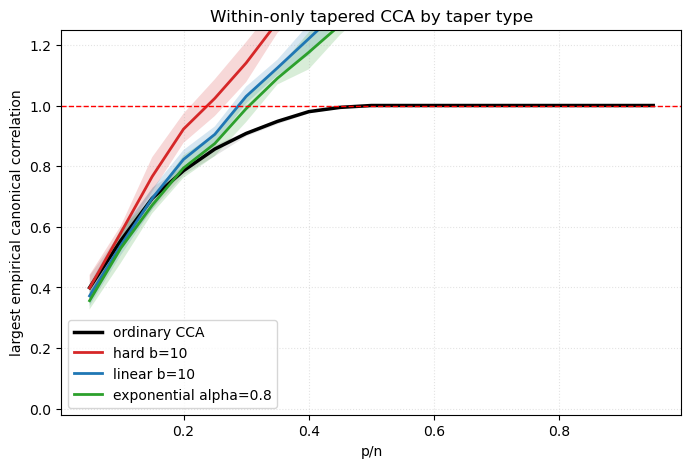

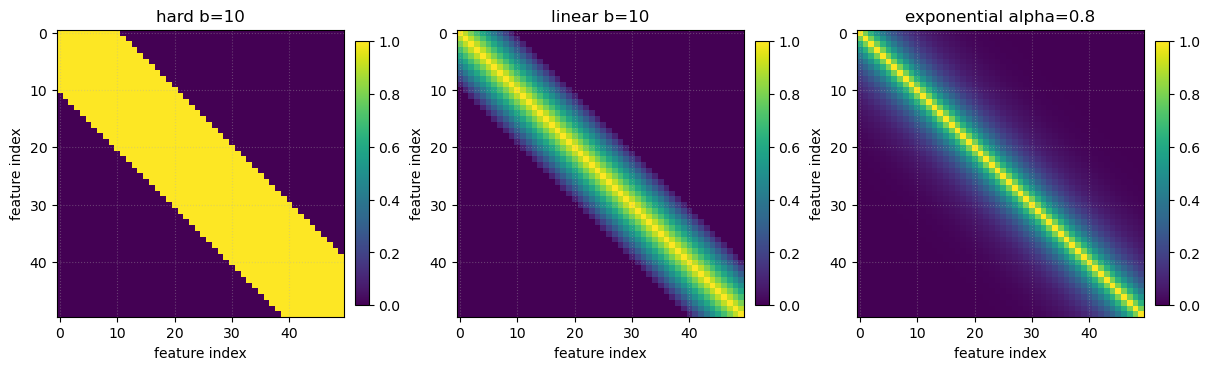

In [7]:
def run_taper_type_comparison(
    specs,
    n=N,
    phi=PHI,
    p_ratios=P_RATIOS,
    n_rep=N_REP,
    ridge=RIDGE,
    seed=RNG_SEED + 4,
):
    rng = np.random.default_rng(seed)
    ordinary = np.zeros((n_rep, len(p_ratios)))
    results = {label: np.zeros((n_rep, len(p_ratios))) for label, _ in specs}

    for rep in range(n_rep):
        for i, ratio in enumerate(p_ratios):
            p = int(np.floor(n * ratio))
            X = ar1_matrix(n, p, phi, rng)
            Y = ar1_matrix(n, p, phi, rng)
            ordinary[rep, i] = cancor(X, Y, k=1)[0]

            for label, kwargs in specs:
                corrs, _, _ = tapered_cancor(X, Y, mode="within", ridge=ridge, **kwargs)
                results[label][rep, i] = corrs[0]
    return ordinary, results

specs = [
    ("hard b=10", {"taper_type": "hard", "bandwidth": 10}),
    ("linear b=10", {"taper_type": "linear", "bandwidth": 10}),
    ("exponential alpha=0.8", {"taper_type": "exponential", "bandwidth": 10, "alpha": 0.8}),
]
ordinary_taper_type, taper_type_results = run_taper_type_comparison(specs)

fig, ax = plt.subplots()
plot_mean_band(ax, P_RATIOS, ordinary_taper_type, "ordinary CCA", "black", alpha=0.10, lw=2.5)
for label, color in zip(taper_type_results, ["tab:red", "tab:blue", "tab:green"]):
    plot_mean_band(ax, P_RATIOS, taper_type_results[label], label, color)
ax.axhline(1, color="red", linestyle="--", lw=1)
ax.set_xlabel("p/n")
ax.set_ylabel("largest empirical canonical correlation")
ax.set_title("Within-only tapered CCA by taper type")
ax.set_ylim(-0.02, 1.25)
ax.legend()
plt.show()

p_demo = 50
matrices = [
    (hard_taper_matrix(p_demo, 10), "hard b=10"),
    (linear_taper_matrix(p_demo, 10), "linear b=10"),
    (exponential_taper_matrix(p_demo, 0.8), "exponential alpha=0.8"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, (mat, title) in zip(axes, matrices):
    im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("feature index")
    ax.set_ylabel("feature index")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Experiment 6: bandwidth sensitivity

Small bandwidths impose stronger locality and can reduce variance at the cost of bias. Large bandwidths are closer to ordinary covariance estimation and can inherit more high-dimensional noise.

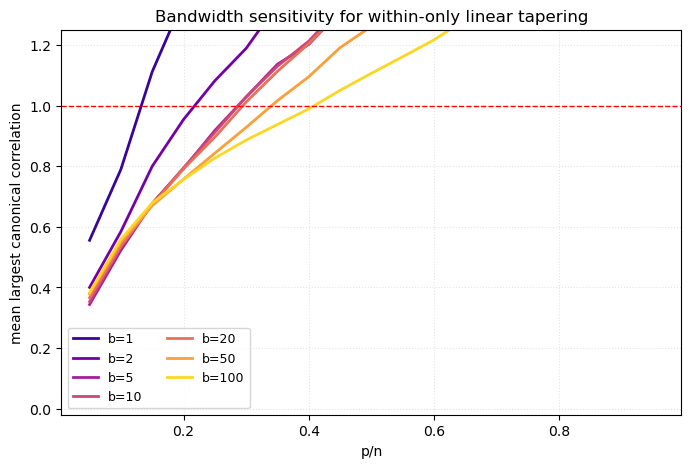

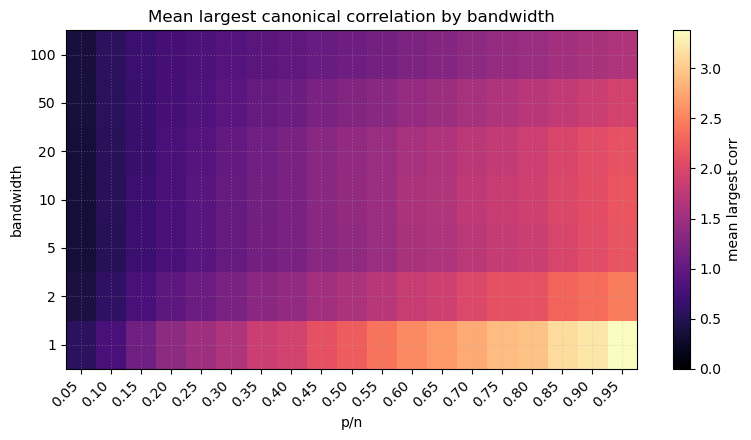

In [8]:
bandwidth_grid = [1, 2, 5, 10, 20, 50, 100]
_, bandwidth_results = run_taper_experiment(
    mode="within",
    taper_type="linear",
    bandwidths=bandwidth_grid,
    ridge=RIDGE,
    seed=RNG_SEED + 5,
)

fig, ax = plt.subplots()
colors = plt.cm.plasma(np.linspace(0.08, 0.92, len(bandwidth_grid)))
for color, b in zip(colors, bandwidth_grid):
    summary = summarize_curves(bandwidth_results[b])
    ax.plot(P_RATIOS, summary["mean"], color=color, lw=2, label=f"b={b}")
ax.axhline(1, color="red", linestyle="--", lw=1)
ax.set_xlabel("p/n")
ax.set_ylabel("mean largest canonical correlation")
ax.set_title("Bandwidth sensitivity for within-only linear tapering")
ax.set_ylim(-0.02, 1.25)
ax.legend(ncol=2, fontsize=9)
plt.show()

heat = np.vstack([summarize_curves(bandwidth_results[b])["mean"] for b in bandwidth_grid])
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(heat, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=max(1.0, heat.max()))
ax.set_xticks(np.arange(len(P_RATIOS)))
ax.set_xticklabels([f"{r:.2f}" for r in P_RATIOS], rotation=45, ha="right")
ax.set_yticks(np.arange(len(bandwidth_grid)))
ax.set_yticklabels(bandwidth_grid)
ax.set_xlabel("p/n")
ax.set_ylabel("bandwidth")
ax.set_title("Mean largest canonical correlation by bandwidth")
fig.colorbar(im, ax=ax, label="mean largest corr")
plt.tight_layout()
plt.show()

## Experiment 7: numerical stability diagnostics

The inverse square root step fails when a tapered covariance matrix has zero, negative, or extremely small eigenvalues. Hard banding is especially risky because the band mask is not guaranteed positive semidefinite. Ridge regularization and eigenvalue clipping prevent numerical blow-ups.

taper       b     ridge      min eig   neg   tiny    condition
--------------------------------------------------------------
hard        1     0e+00   -2.925e-01    65     65          inf
hard        1     1e-03   -2.915e-01    64     64          inf
hard        2     0e+00   -8.756e-02    14     14          inf
hard        2     1e-03   -8.657e-02    14     14          inf
hard        5     0e+00    1.146e-01     0      0     3.73e+01
hard        5     1e-03    1.156e-01     0      0     3.70e+01
hard       10     0e+00    9.727e-02     0      0     4.49e+01
hard       10     1e-03    9.826e-02     0      0     4.45e+01
hard       20     0e+00    3.062e-02     0      0     1.54e+02
hard       20     1e-03    3.160e-02     0      0     1.49e+02
hard       50     0e+00   -2.493e-02     6      6          inf
hard       50     1e-03   -2.394e-02     6      6          inf
linear      1     0e+00    6.311e-01     0      0     1.97e+00
linear      1     1e-03    6.321e-01     0      0     1

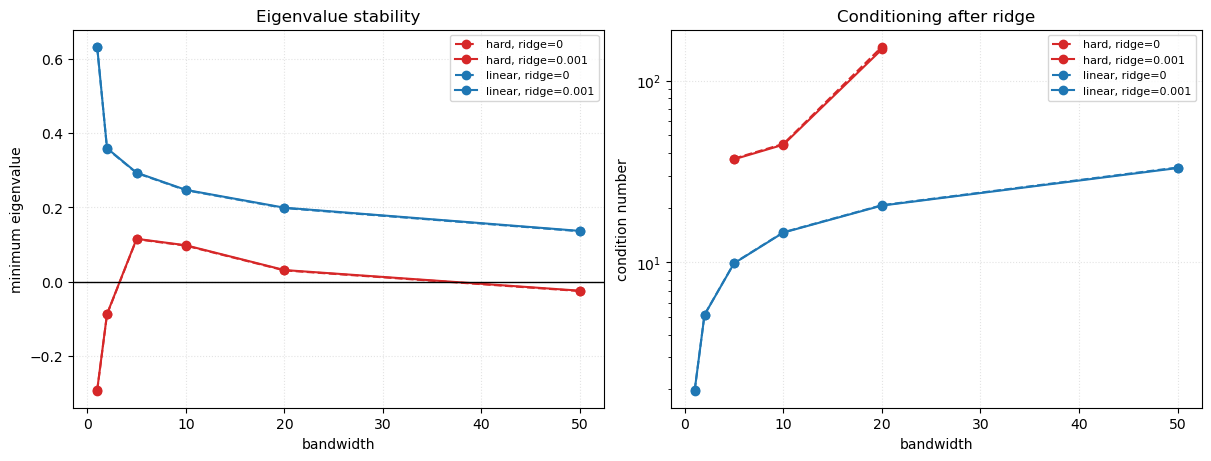

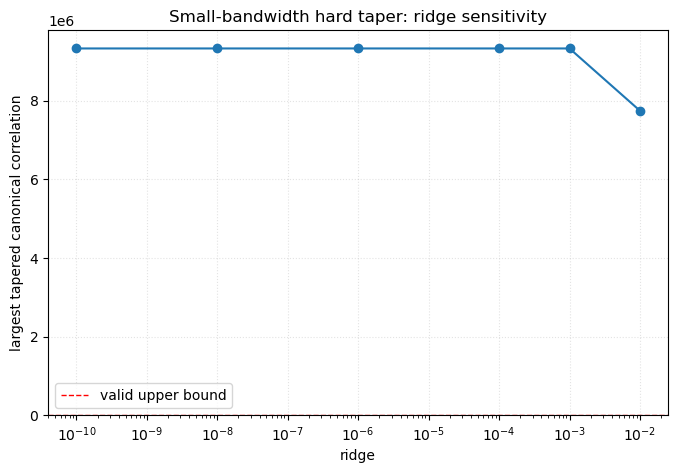

In [9]:
def eig_stats_for_tapered_covariances(
    n=200,
    p=180,
    phi=PHI,
    bandwidths=(1, 2, 5, 10, 20, 50),
    ridge_values=(0.0, 1e-6, 1e-4, 1e-3, 1e-2),
    taper_types=("hard", "linear"),
    seed=RNG_SEED + 6,
):
    rng = np.random.default_rng(seed)
    X = ar1_matrix(n, p, phi, rng)
    Y = ar1_matrix(n, p, phi, rng)
    Sxx = sample_covariance(X)
    Syy = sample_covariance(Y)
    rows = []

    for taper_type in taper_types:
        for b in bandwidths:
            T = taper_matrix(p, taper_type=taper_type, bandwidth=b)
            for ridge in ridge_values:
                row = {"taper": taper_type, "bandwidth": b, "ridge": ridge}
                eig_mins = []
                neg_counts = []
                tiny_counts = []
                conds = []
                for S in (Sxx, Syy):
                    S_tap = (T * S + (T * S).T) / 2
                    scale = np.trace(S_tap) / p
                    if not np.isfinite(scale) or scale <= 0:
                        scale = 1.0
                    eig = np.linalg.eigvalsh(S_tap + ridge * scale * np.eye(p))
                    eig_mins.append(eig.min())
                    neg_counts.append(np.sum(eig < 0))
                    tiny_counts.append(np.sum(eig < 1e-8 * scale))
                    conds.append(np.inf if eig.min() <= 0 else eig.max() / eig.min())
                row["min_eig"] = min(eig_mins)
                row["neg_count"] = int(sum(neg_counts))
                row["tiny_count"] = int(sum(tiny_counts))
                row["condition"] = max(conds)
                rows.append(row)
    return rows

stats = eig_stats_for_tapered_covariances()

header = f"{'taper':8s} {'b':>4s} {'ridge':>9s} {'min eig':>12s} {'neg':>5s} {'tiny':>6s} {'condition':>12s}"
print(header)
print("-" * len(header))
for row in stats:
    if row["ridge"] in (0.0, RIDGE):
        cond = row["condition"]
        cond_text = "inf" if not np.isfinite(cond) else f"{cond:.2e}"
        print(
            f"{row['taper']:8s} {row['bandwidth']:4d} {row['ridge']:9.0e} "
            f"{row['min_eig']:12.3e} {row['neg_count']:5d} {row['tiny_count']:6d} {cond_text:>12s}"
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for taper_type, color in [("hard", "tab:red"), ("linear", "tab:blue")]:
    for ridge, linestyle in [(0.0, "--"), (RIDGE, "-")]:
        subset = [r for r in stats if r["taper"] == taper_type and r["ridge"] == ridge]
        subset = sorted(subset, key=lambda r: r["bandwidth"])
        b = [r["bandwidth"] for r in subset]
        min_eig = [r["min_eig"] for r in subset]
        cond = [np.nan if not np.isfinite(r["condition"]) else r["condition"] for r in subset]
        label = f"{taper_type}, ridge={ridge:g}"
        axes[0].plot(b, min_eig, marker="o", color=color, linestyle=linestyle, label=label)
        axes[1].plot(b, cond, marker="o", color=color, linestyle=linestyle, label=label)

axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel("bandwidth")
axes[0].set_ylabel("minimum eigenvalue")
axes[0].set_title("Eigenvalue stability")
axes[0].legend(fontsize=8)

axes[1].set_yscale("log")
axes[1].set_xlabel("bandwidth")
axes[1].set_ylabel("condition number")
axes[1].set_title("Conditioning after ridge")
axes[1].legend(fontsize=8)
plt.show()

rng = np.random.default_rng(RNG_SEED + 7)
X = ar1_matrix(200, 180, PHI, rng)
Y = ar1_matrix(200, 180, PHI, rng)
ridge_grid = [0.0, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
rho_by_ridge = []
for ridge in ridge_grid:
    corrs, _, _ = tapered_cancor(
        X,
        Y,
        bandwidth=2,
        taper_type="hard",
        mode="within",
        ridge=ridge,
        eig_floor=EIG_FLOOR,
    )
    rho_by_ridge.append(corrs[0])

fig, ax = plt.subplots()
ax.semilogx([max(r, 1e-10) for r in ridge_grid], rho_by_ridge, marker="o")
ax.axhline(1, color="red", linestyle="--", lw=1, label="valid upper bound")
ax.set_xlabel("ridge")
ax.set_ylabel("largest tapered canonical correlation")
ax.set_title("Small-bandwidth hard taper: ridge sensitivity")
ax.set_ylim(0, max(1.25, 1.05 * np.nanmax(rho_by_ridge)))
ax.legend()
plt.show()